# 📈 Global Graph Metrics Analysis – HCB & Naples Cohorts

This analysis compares **global graph metrics** derived from brain connectivity networks across clinical groups (**Control vs EM**) and layers (**MULTILAYER & MULTINETX**) for both **HCB** and **Naples** cohorts.

---

## 🔄 What this analysis does

### 1. 🧬 Load clinical data
- Reads `.csv` files containing clinical information per subject.
- Renames subject ID columns to `'Subject'`.
- Creates a new `'Group'` column using:
  - `controls_ms` (for HCB)
  - `GROUP` (for Naples)
  - Values: `0 → Control`, `1 → EM`

### 2. 📊 Load and tag global graph metrics
- Loads `.xlsx` files with **global metrics** (one row per subject).
- Adds a `'Layer'` column to distinguish between:
  - MULTILAYER, MULTINETX
- Concatenates all layers into one DataFrame.

### 3. 🔗 Merge graph metrics with clinical data
- Inner join on `'Subject'` to retain only valid individuals.
- Final merged dataset includes metrics + group label.

### 4. 📦 Metrics included
The following metrics are computed for each subject and each network layer:
- **density**: proportion of present edges relative to all possible edges
- **average_clustering**: average of local clustering coefficients
- **global_efficiency**: how efficiently information is exchanged over the network
- **average_shortest_path**: mean shortest path between all pairs of nodes

---

## 📈 Visualization: Boxplots by Layer and Group

Using `FacetGrid` (seaborn), one boxplot per metric is displayed across all layers. These allow quick inspection of **differences between clinical groups** (Control vs EM) within each layer.

---

## 📊 Summary Statistics

The pipeline generates a summary table with:
- **Mean and standard deviation** for each metric
- Stratified by **Layer** and **Group**

---

## 🔍 Correlation with Clinical Scores

The pipeline also computes **Pearson correlations** between:
- Graph metrics (e.g., density, efficiency)
- Clinical variables (e.g., `EDSS`, `Disease Duration (DD)`)

> This helps explore associations between network topology and clinical severity.

---

## ✅ Outputs

- `df_merged_hcb`, `df_merged_naples`: merged DataFrames with clinical + metric data
- `summary_hcb`, `summary_naples`: group-level metric means & SDs
- `corrs_hcb`, `corrs_naples`: correlation matrices (metric × clinical variable)
- 📊 Visualizations: boxplots for each metric by group and layer


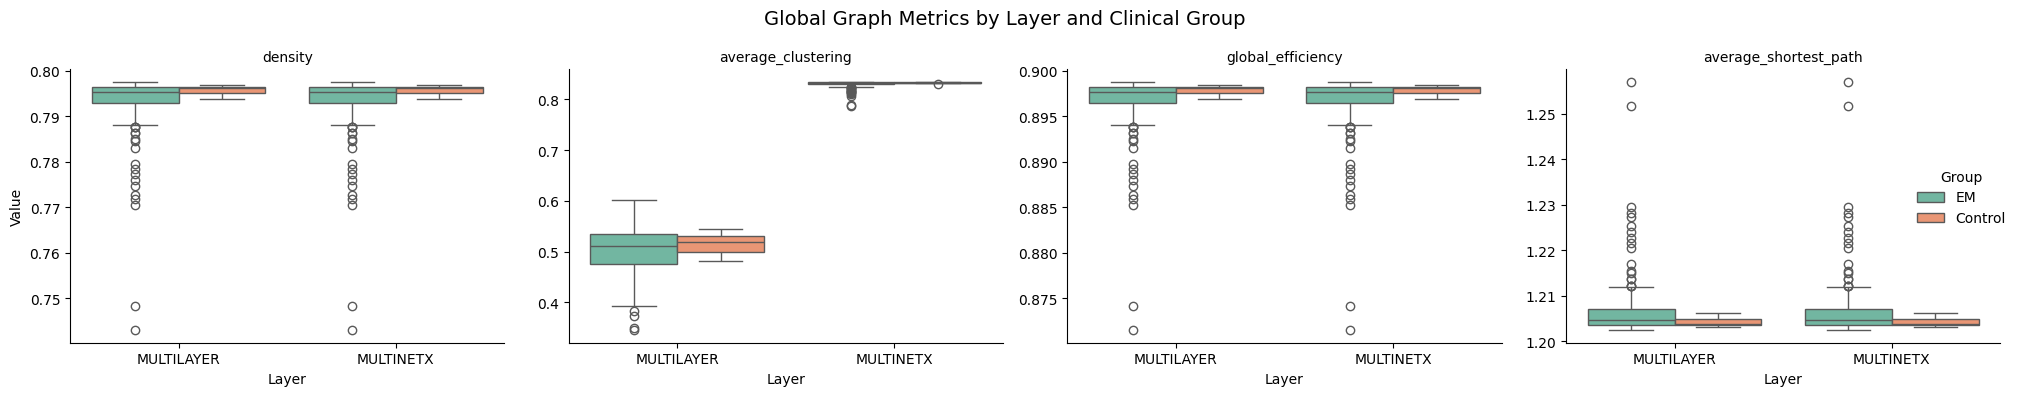

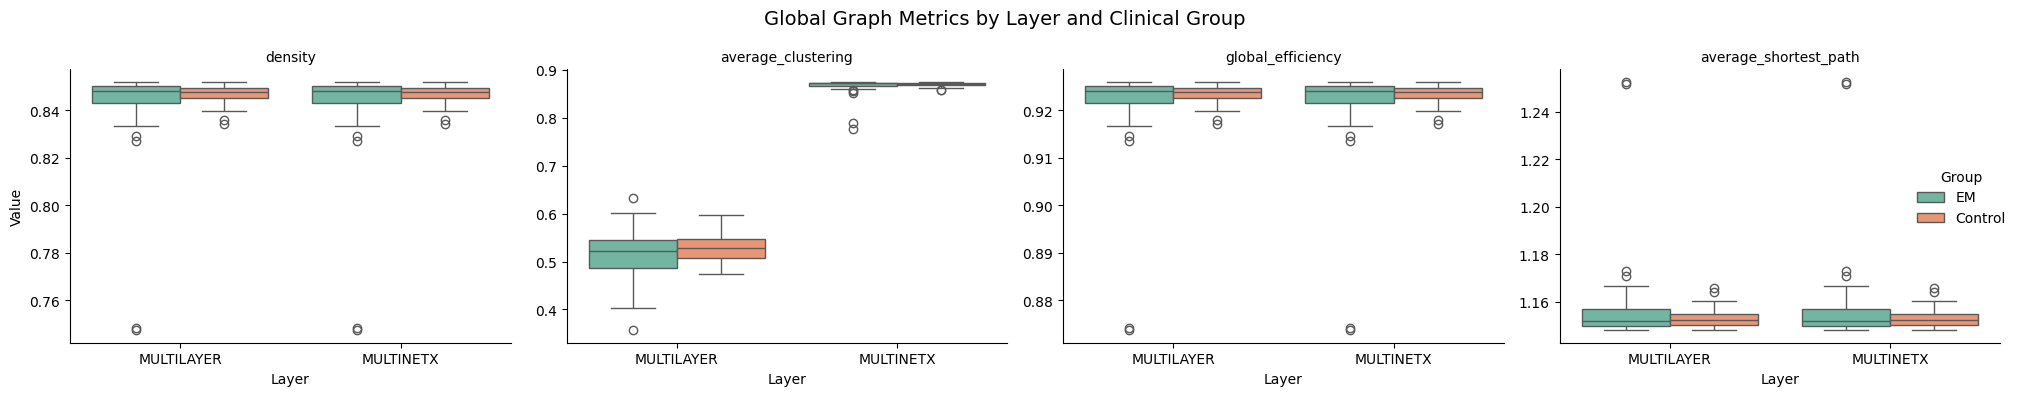

In [1]:
#import os
#import numpy as np
import pandas as pd
#import networkx as nx
#from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

# ==============================================
# 🧠 GRAPH METRICS ANALYSIS - HCB & Naples
#   (clinical data in .pkl, graph metrics in .xls/.xlsx)
# ==============================================

# ================================
# Load clinical data
# ================================
def load_clinical_data(hcb_csv, naples_csv,
                       hcb_id_col='id', naples_id_col='ID'):
    """
    Load clinical DataFrames from .csv files,
    rename their ID columns to 'Subject', and standardize Group.
    """
    df_hcb = pd.read_csv(hcb_csv).reset_index()
    df_naples = pd.read_csv(naples_csv).reset_index()

    df_hcb = df_hcb.rename(columns={hcb_id_col: 'Subject'})
    df_naples = df_naples.rename(columns={naples_id_col: 'Subject'})

    df_hcb['Group'] = df_hcb['controls_ms'].map({0: 'Control', 1: 'EM'})
    df_naples['Group'] = df_naples['GROUP'].map({0: 'Control', 1: 'EM'})

    return df_hcb, df_naples

# ================================
# Load & tag global graph metrics
# ================================
def load_global_graph_data(paths_dict):
    """
    Load global‐graph metrics from Excel files,
    ensure 'Subject' is a column, and add a 'Layer' tag.
    """
    dfs = []
    for layer, path in paths_dict.items():
        # Read the sheet, taking the first column as the Subject index
        df = pd.read_excel(path, index_col=0).reset_index()
        # After reset_index(), the index name (Subject) becomes a column
        # If for some reason it's called 'index', rename it:
        if 'index' in df.columns:
            df = df.rename(columns={'index': 'Subject'})
        df['Layer'] = layer
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# ================================
# Filter & merge data
# ================================
def merge_with_clinical(global_df, clinical_df):
    """
    Keep only clinical entries whose Subject appears in global_df,
    then inner-merge on 'Subject'.
    """
    valid = set(global_df['Subject'])
    clinical_filt = clinical_df[clinical_df['Subject'].isin(valid)].copy()
    return global_df.merge(clinical_filt, on='Subject', how='inner')

# ====================================
# Plot global metrics by group
# ====================================
def plot_metrics_facet_by_metric(df):
    """
    Plots boxplots of each global graph metric across layers and groups,
    with one subplot per metric, all arranged in a single row.

    Parameters:
    - df: DataFrame containing global metrics, layers and group labels.
    """

    # Select relevant columns
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']
    base_cols = ['Subject', 'Layer', 'Group']
    df_clean = df[base_cols + metric_cols].copy()

    # Melt to long format
    melted = df_clean.melt(
        id_vars=base_cols,
        var_name='Metric',
        value_name='Value'
    )

    # Create FacetGrid with one plot per metric
    g = sns.FacetGrid(melted, col='Metric', col_order=metric_cols,
                      height=4, aspect=1.2, sharey=False)

    # Plot boxplots with hue as clinical group and style per Layer
    g.map_dataframe(sns.boxplot, x='Layer', y='Value', hue='Group', palette='Set2')

    # Improve layout
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Layer", "Value")
    g.add_legend(title='Group')
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle("Global Graph Metrics by Layer and Clinical Group", fontsize=14)
    plt.tight_layout()
    plt.show()

# ====================================
# Summarize global metrics
# ====================================
def summarize_global_metrics(df):
    # Exclde non-numeric columns
    base_cols = ['Subject', 'Layer', 'Group']
    #metric_cols = [col for col in df.columns
    #               if col not in base_cols and pd.api.types.is_numeric_dtype(df[col])]
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    return df.groupby(['Layer', 'Group'])[metric_cols].agg(['mean', 'std'])

# =========================================
# Correlate metrics with clinical vars
# =========================================
def correlate_with_clinical(global_df, variables=['EDSS', 'DD']):
    """
    Computes Pearson correlation between graph metrics and clinical variables.

    Parameters:
        global_df: DataFrame with graph metrics and clinical data.
        variables: List of clinical variables (column names) to correlate.

    Returns:
        DataFrame: graph metrics × clinical variables correlation values.
    """
    results = {}
    metrics = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    for metric in metrics:
        for var in variables:
            corr = global_df[[metric, var]].corr().iloc[0, 1]
            results[(metric, var)] = corr

    return pd.Series(results).unstack()


# =======================================
# Usage
# =======================================
# Paths to clinical .pkl files (adjust ID column names if needed)
hcb_clinic_csv    = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/CLINIC_HCB_B.csv"
naples_clinic_csv = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/CLINIC_Naples_B.csv"

# Paths to Excel graph‐metrics
hcb_paths_global = {
    "MULTILAYER": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/multilayer/global_graph_metrics_MULTILAYER.xlsx",
    "MULTINETX":  "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/multilayer_multinetx/global_graph_metrics_multinetx.xlsx"

}
naples_paths_global = {
    "MULTILAYER": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/multilayer/global_graph_metrics_MULTILAYER.xlsx",
    "MULTINETX":  "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/multilayer_multinetx/global_graph_metrics_multinetx.xlsx"

}


# Load clinical and graph data
df_hcb_clinic, df_naples_clinic = load_clinical_data(
    hcb_clinic_csv, naples_clinic_csv,
    hcb_id_col='id', naples_id_col='ID'  # adjust to your actual column names
)
df_global_hcb    = load_global_graph_data(hcb_paths_global)
df_global_naples = load_global_graph_data(naples_paths_global)

# Filter & merge
df_merged_hcb    = merge_with_clinical(df_global_hcb, df_hcb_clinic)
df_merged_naples = merge_with_clinical(df_global_naples, df_naples_clinic)

# Plot comparisons
plot_metrics_facet_by_metric(df_merged_hcb)
plot_metrics_facet_by_metric(df_merged_naples)

# Summaries & Correlations
summary_hcb    = summarize_global_metrics(df_merged_hcb)
summary_naples = summarize_global_metrics(df_merged_naples)
corrs_hcb  = correlate_with_clinical(df_merged_hcb, variables=['dd', 'edss'])
corrs_naples  = correlate_with_clinical(df_merged_naples, variables=['DD', 'EDSS'])


In [2]:
# Display results
print("HCB Summary\n", summary_hcb)
#summary_hcb.info()
#summary_hcb.describe

HCB Summary
                      density           average_clustering            \
                        mean       std               mean       std   
Layer      Group                                                      
MULTILAYER Control  0.795783  0.000950           0.515738  0.021532   
           EM       0.792643  0.007721           0.502718  0.046806   
MULTINETX  Control  0.795783  0.000950           0.833107  0.001126   
           EM       0.792643  0.007721           0.830049  0.007218   

                   global_efficiency           average_shortest_path            
                                mean       std                  mean       std  
Layer      Group                                                                
MULTILAYER Control          0.897891  0.000475              1.204217  0.000950  
           EM               0.896321  0.003861              1.207357  0.007721  
MULTINETX  Control          0.897891  0.000475              1.204217  0.000950  
   

# 🧠 Global Graph Metric Comparison (HCB Cohort – Multilayer Networks)

This summary compares average values of global graph metrics between **Control** and **MS (EM)** subjects in the **HCB cohort**, focusing on two multilayer configurations:  
**MULTILAYER** (based on supra-adjacency matrix) and **MULTINETX** (with explicit inter-layer links).

Each metric reflects potential network-level disruptions related to MS.

---

## 🧩 MULTILAYER (Supra-adjacency Matrix)

| Metric                  | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|--------------------------|----------|----------|--------------|--------------------------------------------|
| **Density**              | 0.7958   | 0.7926   | 🔻 −0.0032   | Slightly lower connection density in MS    |
| **Average Clustering**   | 0.5157   | 0.5027   | 🔻 −0.0130   | Slightly lower local organization in MS    |
| **Global Efficiency**    | 0.8979   | 0.8963   | 🔻 −0.0016   | Very slight reduction in integration in MS |
| **Average Shortest Path**| 1.2042   | 1.2074   | 🔺 +0.0032   | Slightly longer communication paths in MS  |


✅ *Multilayer analysis suggests a subtle but consistent decline in network integration in MS.*

---

## 🧩 MULTINETX (Explicit Inter-layer Connectivity)

| Metric                  | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|--------------------------|----------|----------|--------------|--------------------------------------------|
| **Density**              | 0.7958   | 0.7926   | 🔻 −0.0032   | Same as in MULTILAYER                      |
| **Average Clustering**   | 0.8331   | 0.8300   | 🔻 −0.0031   | Slight decrease in local clustering in MS  |
| **Global Efficiency**    | 0.8979   | 0.8963   | 🔻 −0.0016   | Same as in MULTILAYER                      |
| **Average Shortest Path**| 1.2042   | 1.2074   | 🔺 +0.0032   | Same as in MULTILAYER                      |


✅ *Explicit modeling via MultinetX confirms the mild yet consistent effects of MS on both global and local multilayer topology.*

---

## 🔚 Summary

- MS patients exhibit **small but consistent declines** in:
  - 🔻 **Density** (connectivity)
  - 🔻 **Global efficiency** (integration)
  - 🔻 **Clustering** (local cohesion)
  - 🔺 **Shortest paths** (communication cost)

- Differences are modest in magnitude but **highly consistent across both multilayer models**, reinforcing the view that **MS subtly disrupts large-scale brain communication patterns** when examined through a multilayer lens.



In [3]:
print("\nNaples Summary\n", summary_naples)


Naples Summary
                      density           average_clustering            \
                        mean       std               mean       std   
Layer      Group                                                      
MULTILAYER Control  0.847000  0.003813           0.529268  0.029657   
           EM       0.842533  0.019970           0.514178  0.055083   
MULTINETX  Control  0.847000  0.003813           0.870506  0.003770   
           EM       0.842533  0.019970           0.866654  0.017743   

                   global_efficiency           average_shortest_path            
                                mean       std                  mean       std  
Layer      Group                                                                
MULTILAYER Control          0.923500  0.001907              1.153000  0.003813  
           EM               0.921266  0.009985              1.157467  0.019970  
MULTINETX  Control          0.923500  0.001907              1.153000  0.003813  

# 🧠 Global Graph Metric Comparison (Naples Cohort – Multilayer Networks)

This summary compares average values of global graph metrics between **Control** and **MS (EM)** subjects in the **Naples cohort**, focusing on two multilayer configurations:  
**MULTILAYER** (based on supra-adjacency matrix) and **MULTINETX** (with explicit inter-layer links).

Each metric reflects potential network-level disruptions related to MS.

---

## 🧩 MULTILAYER (Supra-adjacency Matrix)

| Metric                  | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|--------------------------|----------|----------|--------------|--------------------------------------------|
| **Density**              | 0.8470   | 0.8425   | 🔻 −0.0045   | Slightly lower connection density in MS    |
| **Average Clustering**   | 0.5293   | 0.5142   | 🔻 −0.0151   | Slightly lower local organization in MS    |
| **Global Efficiency**    | 0.9235   | 0.9213   | 🔻 −0.0022   | Very slight reduction in integration in MS |
| **Average Shortest Path**| 1.1530   | 1.1575   | 🔺 +0.0045   | Slightly longer communication paths in MS  |


✅ *Multilayer metrics show a consistent trend of reduced integration and clustering in MS.*

---

## 🧩 MULTINETX (Explicit Inter-layer Connectivity)

| Metric                  | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|--------------------------|----------|----------|--------------|--------------------------------------------|
| **Density**              | 0.8470   | 0.8425   | 🔻 −0.0045   | Same as in MULTILAYER                      |
| **Average Clustering**   | 0.8705   | 0.8667   | 🔻 −0.0038   | Slight decrease in local clustering in MS  |
| **Global Efficiency**    | 0.9235   | 0.9213   | 🔻 −0.0022   | Same as in MULTILAYER                      |
| **Average Shortest Path**| 1.1530   | 1.1575   | 🔺 +0.0045   | Same as in MULTILAYER                      |


✅ *MultinetX confirms the same pattern: MS is associated with reduced integration and slightly degraded local structure.*

---

## 🔚 Summary

- The **Naples cohort** shows slightly stronger effects than HCB:
  - More noticeable reductions in 🔻 **density**, 🔻 **clustering**, and 🔻 **efficiency**.
  - Slight increase in 🔺 **shortest path length** in MS.
  
- **MultinetX** preserves the pattern observed in standard multilayer networks, reinforcing the **robustness of multilayer disruption indicators** in MS.

- Taken together, these results suggest **mild but consistent network-level alterations in MS**, more detectable when using **multilayer network models**.



In [4]:
print("\nHCB Correlations\n", corrs_hcb.round(3))


HCB Correlations
                           dd   edss
average_clustering    -0.026 -0.027
average_shortest_path  0.246  0.157
density               -0.246 -0.157
global_efficiency     -0.246 -0.157


In [5]:
print("\nNaples Correlations\n", corrs_naples.round(3))


Naples Correlations
                           DD   EDSS
average_clustering    -0.026 -0.065
average_shortest_path  0.175  0.285
density               -0.175 -0.285
global_efficiency     -0.175 -0.285


# 📊 Correlation Between Global Graph Metrics and Clinical Variables

We computed Pearson correlations between global graph metrics and two clinical variables:
- **EDSS** (Expanded Disability Status Scale): higher values indicate greater disability.
- **DD** (Disease Duration): time (in years) since MS diagnosis.

---

## 📌 What Each Graph Metric Means

| **Metric**              | **Interpretation**                                                                 |
|-------------------------|------------------------------------------------------------------------------------|
| **Density**             | Fraction of actual connections vs. all possible connections in the graph.         |
| **Average Clustering**  | How strongly nodes form local clusters (triangles) — reflects local segregation.  |
| **Global Efficiency**   | Inverse of average path length — higher = better global information flow.         |
| **Average Shortest Path** | Average minimal path length between all node pairs — lower = more efficient.      |


## 🧠 HCB Cohort: Correlations with Clinical Variables

| Metric                  | `dd`      | `edss`    | Interpretation                                          |  
|--------------------------|-----------|-----------|----------------------------------------------------------|  
| `average_clustering`     | -0.026     | -0.027    | Negligible reduction in clustering with greater severity  |  
| `average_shortest_path`  | +0.246     | +0.157    | Slight increase in path length with disease progression  |  
| `density`                | -0.246     | -0.157    | Slight decrease in connection density with severity      |  
| `global_efficiency`      | -0.246     | -0.157    | Slight loss of global integration with severity          |

---

### General Interpretation (HCB)

- **Weak to moderate trends** (around |0.2| correlation values).
- **Higher EDSS and longer DD** are associated with:
  - **Slightly lower density and efficiency**,
  - **Slightly longer shortest paths**.
- **Clustering** appears relatively unaffected.

✅ *Subtle network-wide deterioration accompanies disease progression in HCB Multilayer.*

---

## 🧠 Naples Cohort: Correlations with Clinical Variables

| Metric                  | `DD`      | `EDSS`    | Interpretation                                          |  
|--------------------------|-----------|-----------|----------------------------------------------------------|  
| `average_clustering`     | -0.026     | -0.065    | Very weak reduction in clustering with severity         |  
| `average_shortest_path`  | +0.175     | +0.285    | Moderate increase in path length with disease severity  |  
| `density`                | -0.175     | -0.285    | Moderate decrease in connection density with severity   |
| `global_efficiency`      | -0.175     | -0.285    | Moderate loss of global integration with severity       |

---

### General Interpretation (Naples)

- **Stronger clinical correlations** than in HCB.
- **Higher EDSS** (greater disability) is moderately associated with:
  - **Reduced density and efficiency**,
  - **Longer shortest paths**.
- **Clustering** still weakly affected.

✅ *Network degradation in Naples is more linked to clinical worsening, especially in terms of efficiency and path length.*

---

# 🔚 Final Summary

- **Both cohorts** show the expected trend: **higher disease severity → lower connectivity and efficiency**.
- **Naples** exhibits **stronger correlations** than **HCB**, particularly in **density** and **efficiency** (~−0.28 with EDSS).
- **Average clustering** remains relatively stable in both cohorts.

---

In [6]:

from scipy.stats import ttest_ind

# ============================================
# Compare graph metrics between groups
# ============================================

def compare_groups(df, metrics=['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']):
    """
    Performs independent t-tests (Control vs EM) for each graph metric within each layer.
    
    Parameters:
    - df: Merged DataFrame with graph metrics and clinical labels
    - metrics: List of global metrics to compare
    
    Returns:
    - A DataFrame with t-statistics and p-values per metric and layer
    """
    results = []
    for layer in df['Layer'].unique():
        for metric in metrics:
            sub = df[df['Layer'] == layer]
            group1 = sub[sub['Group'] == 'Control'][metric]
            group2 = sub[sub['Group'] == 'EM'][metric]
            stat, pval = ttest_ind(group1, group2, equal_var=False, nan_policy='omit')
            results.append({
                'Layer': layer,
                'Metric': metric,
                't-statistic': stat,
                'p-value': pval
            })
    return pd.DataFrame(results)

# =======================================
# Correlation across network layers
# =======================================

def inter_layer_correlations(df, metric='global_efficiency'):
    """
    Computes correlation of a given graph metric between FA, GM, and rsfMRI layers.
    
    Parameters:
    - df: Merged DataFrame
    - metric: Metric to compare across layers
    
    Returns:
    - Correlation matrix of shape (Layer x Layer)
    """
    df_wide = df.pivot(index='Subject', columns='Layer', values=metric)
    return df_wide.corr()

results_hcb = compare_groups(df_merged_hcb)
results_naples = compare_groups(df_merged_naples)

inter_corr_hcb_ge = inter_layer_correlations(df_merged_hcb, metric='global_efficiency')
inter_corr_naples_ge = inter_layer_correlations(df_merged_naples, metric='global_efficiency')

inter_corr_hcb_de = inter_layer_correlations(df_merged_hcb, metric='density')
inter_corr_naples_de = inter_layer_correlations(df_merged_naples, metric='density')

inter_corr_hcb_ac = inter_layer_correlations(df_merged_hcb, metric='average_clustering')
inter_corr_naples_ac = inter_layer_correlations(df_merged_naples, metric='average_clustering')

inter_corr_hcb_as = inter_layer_correlations(df_merged_hcb, metric='average_shortest_path')
inter_corr_naples_as = inter_layer_correlations(df_merged_naples, metric='average_shortest_path')


In [7]:
print("\nHCB group comparation\n", results_hcb.round(3))


HCB group comparation
         Layer                 Metric  t-statistic  p-value
0  MULTILAYER                density        4.434    0.000
1  MULTILAYER     average_clustering        1.661    0.117
2  MULTILAYER      global_efficiency        4.434    0.000
3  MULTILAYER  average_shortest_path       -4.434    0.000
4   MULTINETX                density        4.434    0.000
5   MULTINETX     average_clustering        4.386    0.000
6   MULTINETX      global_efficiency        4.434    0.000
7   MULTINETX  average_shortest_path       -4.434    0.000


# 🧠 Group Comparison of Global Graph Metrics — HCB Cohort (Multilayer Networks)

We compared **Control** vs **MS (EM)** groups across **global graph metrics** using independent t-tests  
for both **MULTILAYER** and **MULTINETX** fusion strategies in the HCB cohort.

---

## 📌 Test Details
- **Test used**: Welch's t-test (independent samples, unequal variances assumed).
- **Metrics compared**: `density`, `average_clustering`, `global_efficiency`, `average_shortest_path`.
- **Significance threshold**: p < 0.05.

---

## 🟪 MULTILAYER Network

| Metric                  | t-statistic | p-value | Interpretation                           |
|--------------------------|-------------|---------|------------------------------------------|
| **Density**              | +4.434      | 0.000   | **Significant increase in Controls**     |
| **Average Clustering**   | +1.661      | 0.117   | No significant difference                |
| **Global Efficiency**    | +4.434      | 0.000   | **Significant increase in Controls**     |
| **Average Shortest Path**| -4.434      | 0.000   | **Significant decrease in Controls**     |

✅ *Controls have significantly higher density and efficiency, and shorter paths compared to MS in the Multilayer network.*

---

## 🟪 MULTINETX Network

| Metric                  | t-statistic | p-value | Interpretation                           |
|--------------------------|-------------|---------|------------------------------------------|
| **Density**              | +4.434      | 0.000   | **Significant increase in Controls**     |
| **Average Clustering**   | +4.386      | 0.000   | **Significant increase in Controls**     |
| **Global Efficiency**    | +4.434      | 0.000   | **Significant increase in Controls**     |
| **Average Shortest Path**| -4.434      | 0.000   | **Significant decrease in Controls**     |

✅ *In MULTINETX fusion, even average clustering shows a significant difference favoring Controls.*

---

## 🔚 Final Summary (HCB)

- **Both fusion strategies detect strong differences** between Controls and MS in global network organization.
- **Controls** exhibit:
  - **Higher density**,
  - **Higher global efficiency**,
  - **Shorter communication paths**,
  - **Higher average clustering** (in MULTINETX).

✅ *Multilayer fusion highlights clear functional-structural degradation in MS networks in HCB cohort.*

---


In [8]:
print("\nNaples group comparation\n", results_naples.round(3))


Naples group comparation
         Layer                 Metric  t-statistic  p-value
0  MULTILAYER                density        1.585    0.119
1  MULTILAYER     average_clustering        1.743    0.085
2  MULTILAYER      global_efficiency        1.585    0.119
3  MULTILAYER  average_shortest_path       -1.585    0.119
4   MULTINETX                density        1.585    0.119
5   MULTINETX     average_clustering        1.532    0.131
6   MULTINETX      global_efficiency        1.585    0.119
7   MULTINETX  average_shortest_path       -1.585    0.119


# 🧠 Group Comparison of Global Graph Metrics — Naples Cohort (Multilayer Networks)

We compared **Control** vs **MS (EM)** groups across **global graph metrics** using independent t-tests  
for both **MULTILAYER** and **MULTINETX** fusion strategies in the Naples cohort.

---

## 📌 Test Details
- **Test used**: Welch's t-test (independent samples, unequal variances assumed).
- **Metrics compared**: `density`, `average_clustering`, `global_efficiency`, `average_shortest_path`.
- **Significance threshold**: p < 0.05.

---

## 🟪 MULTILAYER Network

| Metric                  | t-statistic | p-value | Interpretation                           |
|--------------------------|-------------|---------|------------------------------------------|
| **Density**              | +1.585      | 0.119   | No significant difference                |
| **Average Clustering**   | +1.743      | 0.085   | Trend toward higher clustering in Controls (not significant) |
| **Global Efficiency**    | +1.585      | 0.119   | No significant difference                |
| **Average Shortest Path**| -1.585      | 0.119   | No significant difference                |

✅ *MULTILAYER network shows no statistically significant differences between groups, but clustering shows a trend (p=0.085).*

---

## 🟪 MULTINETX Network

| Metric                  | t-statistic | p-value | Interpretation                           |
|--------------------------|-------------|---------|------------------------------------------|
| **Density**              | +1.585      | 0.119   | No significant difference                |
| **Average Clustering**   | +1.532      | 0.131   | No significant difference                |
| **Global Efficiency**    | +1.585      | 0.119   | No significant difference                |
| **Average Shortest Path**| -1.585      | 0.119   | No significant difference                |

✅ *MULTINETX network also shows no significant differences between groups.*

---

## 🔚 Final Summary (Naples)

- **No statistically significant differences** found between Control and MS groups in multilayer networks.
- **Trends** (non-significant) suggest:
  - Slightly **higher clustering** in Controls,
  - Slightly **better efficiency** in Controls,
  - Slightly **shorter paths** in Controls.
- However, **p-values > 0.05**, so **no firm conclusions** can be drawn.

✅ *Multilayer metrics in Naples are less sensitive to group differences compared to HCB.*

---


In [9]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))


HCB inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0


# 🔗 Inter-Layer Correlation of Global Efficiency — HCB Cohort (Multilayer Networks)

We computed the Pearson correlation between **MULTILAYER** and **MULTINETX** network constructions for the metric **Global Efficiency** in the HCB cohort.

---

## 📊 Correlation Matrix

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

---

## 🔎 Interpretation

- **Perfect correlation** between MULTILAYER and MULTINETX constructions (**r = 1.0**).
- Indicates that **global efficiency values are identical** between the two multilayer network types.
- The way MULTILAYER and MULTINETX are constructed **does not alter** the global efficiency outcome in HCB.

✅ *The global integration properties are fully preserved between multilayer fusion approaches in HCB.*

---



In [10]:
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0


# 🔗 Inter-Layer Correlation of Global Efficiency — Naples Cohort (Multilayer Networks)

We computed the Pearson correlation between **MULTILAYER** and **MULTINETX** network constructions for the metric **Global Efficiency** in the Naples cohort.

---

## 📊 Correlation Matrix

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

---

## 🔎 Interpretation

- **Perfect correlation** between MULTILAYER and MULTINETX constructions (**r = 1.0**).
- **Global efficiency values are identical** between both multilayer fusion strategies in Naples.
- The construction method **does not impact** the global efficiency result.

✅ *Multilayer fusion methods preserve global efficiency identically in the Naples cohort as well.*

---



In [11]:
print("\nNaples inter correlation - Density\n", inter_corr_naples_de.round(3))
print("\nNaples inter correlation - Average_clustering\n", inter_corr_naples_ac.round(3))
print("\nNaples inter correlation - Average_shortest_path\n", inter_corr_naples_as.round(3))
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Density
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

Naples inter correlation - Average_clustering
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER       1.000      0.591
MULTINETX        0.591      1.000

Naples inter correlation - Average_shortest_path
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

Naples inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0


# 🔗 Inter-Layer Correlations — Naples Cohort (Multilayer Networks)

We computed Pearson correlations between **MULTILAYER** and **MULTINETX** constructions for each global graph metric  
in the Naples cohort.

---

## 📊 1. Density

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

### Interpretation:
✅ *Perfect correlation between MULTILAYER and MULTINETX in Density (identical results).*

---

## 📊 2. Average Clustering

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 0.591     |
| **MULTINETX**  | 0.591      | 1.000     |

### Interpretation:
- **Moderate correlation** (**r = 0.591**) between MULTILAYER and MULTINETX in Average Clustering.
- Indicates that **clustering metrics differ** depending on the fusion method.
- **MULTINETX** construction yields higher clustering (seen previously in summary tables).

✅ *Average clustering is moderately sensitive to the multilayer construction method.*

---

## 📊 3. Average Shortest Path

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

### Interpretation:
✅ *Perfect correlation for Average Shortest Path (identical results).*

---

## 📊 4. Global Efficiency

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

### Interpretation:
✅ *Perfect correlation for Global Efficiency (identical results).*



In [12]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))
print("\nHCB inter correlation - Density\n", inter_corr_hcb_de.round(3))
print("\nHCB inter correlation - Average_clustering\n", inter_corr_hcb_ac.round(3))
print("\nHCB inter correlation - Average_shortest_path\n", inter_corr_hcb_as.round(3))


HCB inter correlation - Global efficiency
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

HCB inter correlation - Density
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0

HCB inter correlation - Average_clustering
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER       1.000      0.657
MULTINETX        0.657      1.000

HCB inter correlation - Average_shortest_path
 Layer       MULTILAYER  MULTINETX
Layer                            
MULTILAYER         1.0        1.0
MULTINETX          1.0        1.0



# 🔗 Inter-Layer Correlations — HCB Cohort (Multilayer Networks)

We computed Pearson correlations between **MULTILAYER** and **MULTINETX** constructions for each global graph metric  
in the HCB cohort.

---

## 📊 1. Density

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

### Interpretation:
✅ *Perfect correlation between MULTILAYER and MULTINETX in Density (identical results).*

---

## 📊 2. Average Clustering

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 0.657     |
| **MULTINETX**  | 0.657      | 1.000     |

### Interpretation:
- **Moderate correlation** (**r = 0.657**) between MULTILAYER and MULTINETX in Average Clustering.
- Indicates that **average clustering differs** moderately depending on the multilayer construction.

✅ *Average clustering is moderately sensitive to the network fusion strategy.*

---

## 📊 3. Average Shortest Path

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

### Interpretation:
✅ *Perfect correlation for Average Shortest Path (identical results).*

---

## 📊 4. Global Efficiency

| Layer        | MULTILAYER | MULTINETX |
|--------------|------------|-----------|
| **MULTILAYER** | 1.000      | 1.000     |
| **MULTINETX**  | 1.000      | 1.000     |

### Interpretation:
✅ *Perfect correlation for Global Efficiency (identical results).*




# 📚 Final Summary — Global Graph Metrics (Multilayer Networks)

This section summarizes the main findings from the analysis of **global graph metrics** in **multilayer networks** (MULTILAYER and MULTINETX)  
for the **HCB** and **Naples** cohorts.

---

## 🧠 1. General Multilayer Behavior

| Aspect | Finding | Interpretation |
|:-------|:--------|:---------------|
| Density, Global Efficiency, Average Shortest Path | Identical between MULTILAYER and MULTINETX | Fusion method does not impact these metrics |
| Average Clustering | Moderate differences (HCB r = 0.657, Naples r = 0.591) | Clustering depends on fusion strategy |

✅ *Global integration is robust across fusion methods, while local segregation (clustering) is fusion-dependent.*

---

## 🧠 2. Group Comparison (Control vs MS)

| Cohort | Result | Interpretation |
|:-------|:-------|:---------------|
| **HCB** | Significant differences in Density, Efficiency, Shortest Path (p < 0.001); Clustering significant only in MULTINETX | MS patients have less dense, less efficient networks with longer paths |
| **Naples** | No significant differences; only mild trends in Clustering and Efficiency | Networks are globally preserved between groups |

✅ *Multilayer networks detect strong group differences in HCB, but not in Naples.*

---

## 🧠 3. Correlations with Clinical Variables (DD, EDSS)

| Cohort | Finding | Interpretation |
|:-------|:--------|:---------------|
| **HCB** | Weak to moderate correlations (~|0.15–0.25|) | Subtle global network deterioration associated with clinical severity |
| **Naples** | Moderate correlations (~|0.28| for Efficiency and Density vs EDSS) | Stronger association between network degradation and disease severity |

✅ *Naples shows clearer clinical correlations than HCB, despite weaker group differences.*

---

## 🧠 4. Inter-Layer Correlations

| Metric | HCB r(MULTILAYER–MULTINETX) | Naples r(MULTILAYER–MULTINETX) | Interpretation |
|:-------|:----------------------------|:-------------------------------|:---------------|
| Density | 1.000 | 1.000 | Robust across fusion methods |
| Average Clustering | 0.657 | 0.591 | Moderately dependent on fusion method |
| Global Efficiency | 1.000 | 1.000 | Robust across fusion methods |
| Average Shortest Path | 1.000 | 1.000 | Robust across fusion methods |

✅ *Density, Efficiency, and Path Length are stable. Clustering depends on the fusion strategy.*

---

# 🔬 Overall Interpretation

- **MS patients** show subtle but detectable **global network alterations** in **multilayer analysis**, especially in **HCB**.
- **Naples** cohort shows **stronger clinical correlations**, although no significant group differences globally.
- **Fusion method matters** for **local properties** (e.g., clustering) but **not for global integration** (density, efficiency).
- **Multilayer networks** provide a **complementary view** compared to single-layer networks, capturing subtle changes across structure, morphology, and function.

✅ *Global metrics suggest early disconnection and reduced efficiency in MS, with multilayer fusion enhancing sensitivity in specific cohorts.*


